In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('~/practice/cross sections/nu_mu_bar_H2_cc_n.txt', delim_whitespace=True, header=None)
plt.plot(df[0], df[1])
plt.show()

<Figure size 640x480 with 1 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '~/practice/cross sections/nu_mu_bar_H2_cc_n.txt'

data = pd.read_csv(file_path, delim_whitespace=True, header=None)

data.columns = ['energy', 'cross section']

# Plot
plt.plot(data['energy'], data['cross section'], marker='o')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'Cross Section (1e$^{-38}$ cm$^2$)')
plt.title(r'Cross Sections of $\bar{\mu}$ and Neutrons')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("nu_mu_bar_H2_cc_n.png", dpi=300)

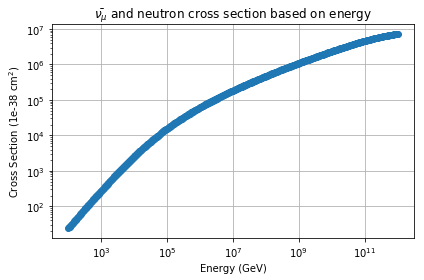

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '~/practice/nu_mu_bar_H2_cc_n.txt'

data = pd.read_csv(file_path, delim_whitespace=True, header=None)

data.columns = ['energy', 'cross section']

plt.loglog(data['energy'], data['cross section'], marker='o')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'Cross Section (1e-38 cm$^2$)')
plt.title(r'$\bar{\nu_{\mu}}$ and neutron cross section based on energy')
plt.grid(True)
plt.tight_layout()
plt.show()

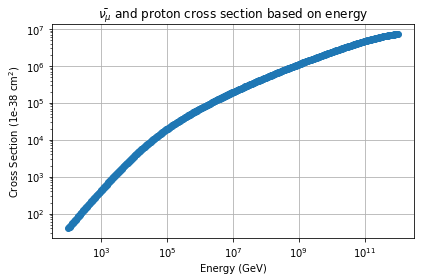

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '~/practice/nu_mu_bar_H2_cc_p.txt'

data = pd.read_csv(file_path, delim_whitespace=True, header=None)

data.columns = ['energy', 'cross section']

plt.loglog(data['energy'], data['cross section'], marker='o')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'Cross Section (1e-38 cm$^2$)')
plt.title(r'$\bar{\nu_{\mu}}$ and proton cross section based on energy')
plt.grid(True)
plt.tight_layout()
plt.show()

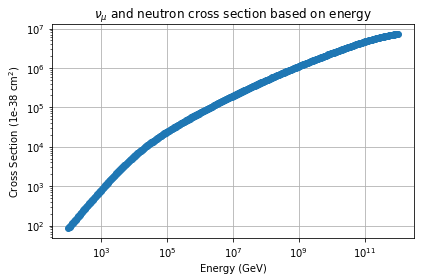

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '~/practice/nu_mu_H2_cc_n.txt'

data = pd.read_csv(file_path, delim_whitespace=True, header=None)

data.columns = ['energy', 'cross section']

plt.loglog(data['energy'], data['cross section'], marker='o')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'Cross Section (1e-38 cm$^2$)')
plt.title(r'$\nu_{\mu}$ and neutron cross section based on energy')
plt.grid(True)
plt.tight_layout()
plt.show()

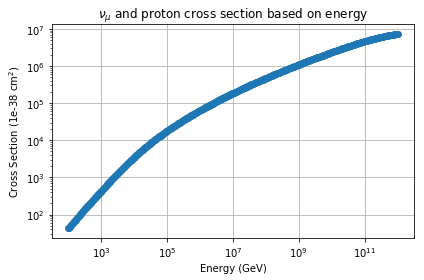

In [137]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = '~/practice/nu_mu_H2_cc_p.txt'

data = pd.read_csv(file_path, delim_whitespace=True, header=None)

data.columns = ['energy', 'cross section']

plt.loglog(data['energy'], data['cross section'], marker='o')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'Cross Section (1e-38 cm$^2$)')
plt.title(r'$\nu_{\mu}$ and proton cross section based on energy')
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
# time calculation
days = 500
hr = days * 24
t = hr * 3600 # in seconds
print(t)

# N_det calcuation
tons = 40000
kg = tons * 1000
mol = kg /0.055845
atoms = mol * 6.02e23
N_det = atoms
# N_det = ar_atoms * 36 # 18 protons and 18 neutrons
print(N_det)

43200000
4.3119348195899365e+32


In [9]:
with open("nu_mu_Fe56_cc_tot.txt", "r") as tot, open("avg_xs.txt", "w") as avg:
    for line in tot:
        if not line.strip():
            continue
        # For line1
        parts = line.strip().split()
        energy = float(parts[0])
        xs = float(parts[1]) if len(parts) > 1 and parts[1] != '' else 0.0
        xs *= 1e-38
        avg.write(f"{energy} {xs}\n")

In [10]:
from scipy.interpolate import interp1d, interp2d
import numpy as np

flx = np.loadtxt("flux.txt")
avg = np.loadtxt("avg_xs.txt")

energy_vals_xs = avg[:, 0]
xs_vals = avg[:, 1]

e_min = 1.5
e_max = 120
theta_min = 0
theta_max = np.pi

energy_vals_flx = np.unique(flx[:, 0])
theta = np.unique(flx[:, 1])
key = theta[0]
with open("flux_only.txt", "w") as flx_o:
    for i in range(len(flx[:, 0])):
        if key != flx[i][1]:
            key = flx[i][1]
            flx_o.write(f"\n")
        flx_o.write(f"{flx[i][2]} ")

xs_interp = interp1d(np.log10(energy_vals_xs), xs_vals, kind='cubic', bounds_error=False, fill_value=0)

In [11]:
data = np.loadtxt("flux_only.txt")

# Sort the data by the first column so identical keys are grouped together
data = data[data[:, 0].argsort()]

# Initialize tracking variables
current_key = None
current_group = []
grouped_arrays = []

# Loop over each row
for row in data:
    key = row[0]  # Value in the first column
    if current_key is None:
        current_key = key
    
    if key == current_key:
        current_group.append(row)
    else:
        # When key changes, save the current group and start a new one
        grouped_arrays.append(np.array(current_group))
        current_group = [row]
        current_key = key

# Don't forget to add the last group after the loop ends
if current_group:
    grouped_arrays.append(np.array(current_group))

# Example: print all groups
for group in grouped_arrays:
    print(group)


[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.55665944e-36
  3.96890734e-38 2.16851568e-40]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.69570083e-36
  4.06091131e-38 2.18511211e-40]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.66799866e-36
  4.04226334e-38 2.18141094e-40]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.69570083e-36
  4.06091131e-38 2.18511211e-40]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.54966250e-36
  3.96246319e-38 2.16617410e-40]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.55665944e-36
  3.96890734e-38 2.16851568e-40]]


In [12]:
flux_interp = interp2d(np.log10(energy_vals_flx), theta, grouped_arrays, kind='cubic', fill_value=0)

In [13]:
from scipy.integrate import quad

def integrand(theta, u):
    return xs_interp(u) * flux_interp(u, theta) * np.sin(theta) * (10 ** u) * np.log(10)

def inner_integral(u):
    result,error = quad(integrand, theta_min, theta_max, args=(u,))
    return result

result, error = quad(inner_integral, np.log10(e_min), np.log10(e_max))

print(result)

8.703543202630393e-39


In [14]:
N = result * 2 * np.pi * t * N_det
print(N)

1018.6661898389877


In [7]:
with open("nu_mu_H2_cc_n.txt", "r") as xsn, open("nu_mu_H2_cc_p.txt", "r") as xsp, open("avg_xs.txt", "w") as avg:
    for line1, line2 in zip(xsn, xsp):
        if not line1.strip() or not line2.strip():
            continue
        # For line1
        parts1 = line1.strip().split()
        energy_n = float(parts1[0])
        xs_n = float(parts1[1]) if len(parts1) > 1 and parts1[1] != '' else 0.0

        # For line2
        parts2 = line2.strip().split()
        energy_p = float(parts2[0])
        xs_p = float(parts2[1]) if len(parts2) > 1 and parts2[1] != '' else 0.0
        
        if xs_n != 0 and xs_p != 0:
            xs = (xs_n + xs_p) / 2
            xs *= 1e-38
            avg.write(f"{energy_n} {xs}\n")
        elif xs_n != 0 and xs_p == 0:
            xs = xs_n * 1e-38
            avg.write(f"{energy_n} {xs_n}\n")
        elif xs_p != 0 and xs_n == 0:
            xs = xs_p * 1e-38
            avg.write(f"{energy_n} {xs_p}\n")
        else:
            avg.write(f"{energy_n}\n")
        

In [63]:
from scipy.integrate import quad

def integrand(theta, energy):
    return xs_interp(energy) * flux_interp(energy, theta) * np.sin(theta)

def inner_integral(energy):
    result, error = quad(integrand, theta_min, theta_max, args=(energy,))
    return result

result, error = quad(inner_integral, e_min, e_max)

print(result)

0.0


In [18]:
from scipy.integrate import dblquad

def integrand(energy, theta):
    return flux_interp(theta, energy) * xs_interp(energy) * np.sin(theta) #* energy * np.log(10)
result, error = dblquad(integrand, theta_min, theta_max, lambda x: e_min, lambda x: e_max, epsabs=1e-5, epsrel=1e-5)
print(result)

0.0


# Plotting the flux data

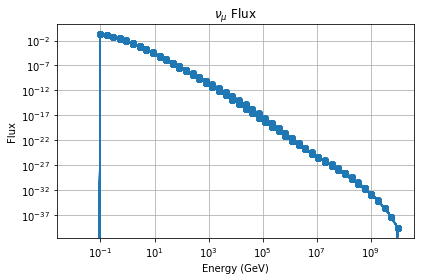

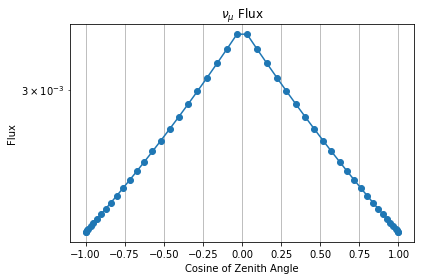

In [161]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = '~/practice/flux.txt'

data = pd.read_csv(file_path, delim_whitespace=True, header=None)

data.columns = ['energy', 'zenith angle', 'flux']

plt.loglog(data['energy'], data['flux'], marker='o')
plt.xlabel('Energy (GeV)')
plt.ylabel(r'Flux')
plt.title(r'$\nu_{\mu}$ Flux')
plt.grid(True)
plt.tight_layout()
plt.show()

flx = np.loadtxt("flux.txt")

zenith = []
flux = []
for i in range(len(flx[:, 0])):
    if flx[i][0] == 1.5998587196060574:
        zenith.append(flx[i][1])
        flux.append(flx[i][2])
        
plt.semilogy(np.cos(np.array(zenith)), np.array(flux), marker='o')
plt.xlabel('Cosine of Zenith Angle')
plt.ylabel(r'Flux')
plt.title(r'$\nu_{\mu}$ Flux')
plt.grid(True)
plt.tight_layout()
plt.show()

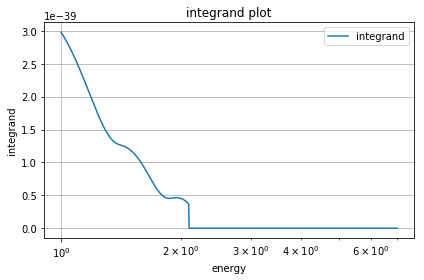

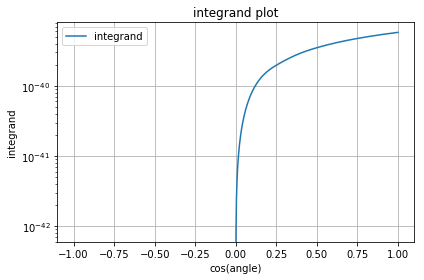

In [160]:
import matplotlib.pyplot as plt

log_energy = np.linspace(1, 7, 1000)
vec_integrand = np.vectorize(integrand)
inte = vec_integrand(np.pi / 2, energy)
inte = np.nan_to_num(inte, nan=0.0, posinf=0.0, neginf=0.0)
plt.semilogx(energy, inte, label='integrand')
plt.xlabel('energy')
plt.ylabel('integrand')
plt.title('integrand plot')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


angle = np.linspace(0, np.pi, 1000)
cos = np.cos(angle)
vec_integrand = np.vectorize(integrand)
inte = vec_integrand(cos / 2, 1.2)
inte = np.nan_to_num(inte, nan=0.0, posinf=0.0, neginf=0.0)
plt.semilogy(cos, inte, label='integrand')
plt.xlabel('cos(angle)')
plt.ylabel('integrand')
plt.title('integrand plot')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [125]:
energy = np.linspace(1, 7, 1000)
vec_xs = np.vectorize(xs_interp)
xs_vals = vec_xs(energy)

# Clean NaNs/infs
xs_vals = np.nan_to_num(xs_vals, nan=0.0, posinf=0.0, neginf=0.0)

plt.plot(energy, xs_vals, label='xs_interp(log10(E))')
plt.xlabel('log10(Energy [GeV])')
plt.ylabel('Cross Section')
plt.title('Interpolated Cross Section vs log10(E)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

TypeError: 'numpy.ndarray' object is not callable